# NB08 — Hourly BTC-USD Next-Hour Prediction with Walk-Forward Validation

Asks: at hourly resolution on BTC-USD, can a model predict the next-hour (and next-4h) log return better than the trivial "predict zero" baseline, and does the hierarchy representation contribute anything beyond plain price/volume features?

**Data:** yfinance `BTC-USD` `period="720d", interval="1h"` — ≈17k hourly bars (~2 years).

**Targets, both per horizon H ∈ {1h, 4h}:**

- `future_log_return` = `log(close_{t+H} / close_t)` (regression target)
- `future_direction` = `sign(future_log_return)` (classification target)

**Models:**

- `baseline` — RF on hourly price/volume features (same shape as NB05's baseline, retimed)
- `hierarchy` — `baseline` + 4 soft-membership columns from a depth-2 hierarchy over (greed, fear)

**Trivial baselines, scored on every fold:**

- `zero` — predict 0 return / random direction
- `persistence` — predict `return_{t+H} = return_t` (for regression) and direction of last bar
- `majority` — predict class with higher training frequency

**Walk-forward:** 5 expanding-window folds. Each fold tunes RF hyperparameters on the last 15% of its training slice, refits on the full slice, and scores on the next 10% of data.

**Metrics:** MAE, RMSE, Spearman IC (regression); accuracy, balanced accuracy, ROC AUC (classification). Pooled across folds for: calibration plot of P(up), hit-ratio by predicted-return decile, IC stability across folds.

**Honest expectations.** Predicting next-hour BTC return from OHLCV alone is *hard*. State-of-the-art institutional models with order-book data hit ~52% direction accuracy. An honest result here is "the model has a positive IC and is calibrated, with direction accuracy in the 50.5–52% range." Anything substantially higher is suspect (likely leakage). The point of this notebook is not to find a profitable strategy — it's to measure whether the hierarchy adds any detectable signal at this resolution.


In [1]:
import math, os, json, random
from dataclasses import dataclass
from datetime import datetime
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, balanced_accuracy_score, roc_auc_score,
)
from scipy.stats import spearmanr

SEED = 42
random.seed(SEED); np.random.seed(SEED)

TICKER = "BTC-USD"
PERIOD = "720d"
INTERVAL = "1h"

HORIZONS = [1, 4]            # next-hour, next-4h
N_FOLDS = 5
MIN_TRAIN_FRACTION = 0.40    # first test fold starts after 40% of data
VAL_FRACTION_WITHIN_TRAIN = 0.15
TEST_FRACTION_PER_FOLD = 0.10

MAX_HIERARCHY_DEPTH = 2      # K = 4 leaves (NB07's sweet spot for hierarchy as features)
MIN_LEAF_COUNT = 200

RF_N_ESTIMATORS = 200
RF_GRID = [
    {"max_depth": md_, "min_samples_leaf": msl}
    for md_ in (6, 10) for msl in (20, 50)
]                            # 4 combos to keep WF runtime manageable

JOURNAL_PATH = "EXPERIMENTS.md"


## Data + features adapted to hourly scale

Same feature shape as NB05/06 but the rolling windows are reinterpreted as hours rather than trading days. Concretely: "vol_10" (10-day daily-vol) becomes "vol_168" (1-week of hourly vol), and so on. The greed/fear pressure formulas keep the same coefficients, just retargeted to the renamed feature columns.


In [2]:
def load_yfinance_hourly(ticker, period, interval):
    raw = yf.download(tickers=ticker, period=period, interval=interval,
                     auto_adjust=True, progress=False, group_by="column")
    if raw.empty:
        raise RuntimeError(f"No data returned for {ticker}")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [c[0].lower() for c in raw.columns]
    else:
        raw.columns = [str(c).lower() for c in raw.columns]
    df = raw[["open","high","low","close","volume"]].copy().reset_index()
    # The index column is either 'index' or 'Datetime' depending on yfinance version
    ts_col = [c for c in df.columns if c not in ("open","high","low","close","volume")][0]
    df = df.rename(columns={ts_col: "ts"})
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    return df.dropna().sort_values("ts").reset_index(drop=True)


def rolling_zscore(x, w, eps=1e-8):
    m = x.rolling(w, min_periods=max(3, w // 3)).mean()
    s = x.rolling(w, min_periods=max(3, w // 3)).std()
    return (x - m) / (s + eps)


def sigmoid_np(x): return 1.0 / (1.0 + np.exp(-x))


def make_hourly_features(df, horizons):
    out = df.copy()
    # Log returns at various lookbacks (hours)
    for lag in (1, 2, 4, 12, 24, 168):
        out[f"ret_{lag}"] = np.log(out["close"] / out["close"].shift(lag))
    out["range_pct"] = (out["high"] - out["low"]) / out["close"]
    out["open_close_pct"] = (out["close"] - out["open"]) / out["open"]
    # Hourly-bar return volatility over windows (in hours)
    for w in (24, 168, 720):
        out[f"vol_{w}"] = out["ret_1"].rolling(w).std()
    for w in (24, 168, 720):
        out[f"ma_{w}"] = out["close"].rolling(w).mean()
        out[f"price_to_ma_{w}"] = out["close"] / out[f"ma_{w}"] - 1.0
    out["volume_log"] = np.log1p(out["volume"])
    out["volume_z_168"] = rolling_zscore(out["volume_log"], 168)
    for w in (168, 720):
        out[f"rolling_max_{w}"] = out["close"].rolling(w).max()
        out[f"drawdown_{w}"] = out["close"] / out[f"rolling_max_{w}"] - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_168"], 720)
    out["fear_pressure"] = (
        -4.0*out["drawdown_168"] - 2.0*out["drawdown_720"]
        + 8.0*out["vol_168"] + 0.35*out["volume_z_168"]
        - 0.50*out["ret_24"]
    )
    out["greed_pressure"] = (
        1.50*out["trend_pressure"] + 2.00*out["price_to_ma_168"]
        + 1.00*out["ret_168"] + 0.20*out["volume_z_168"]
        - 3.00*out["vol_720"]
    )
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    # Targets — one set per horizon
    for h in horizons:
        out[f"future_log_return_{h}"] = np.log(out["close"].shift(-h) / out["close"])
        out[f"future_direction_{h}"] = (out[f"future_log_return_{h}"] > 0).astype(int)
    return out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


BASELINE_FEATURES = [
    "ret_1", "ret_2", "ret_4", "ret_12", "ret_24", "ret_168",
    "range_pct", "open_close_pct",
    "vol_24", "vol_168", "vol_720",
    "price_to_ma_24", "price_to_ma_168", "price_to_ma_720",
    "volume_z_168", "drawdown_168", "drawdown_720",
]

df_raw = load_yfinance_hourly(TICKER, PERIOD, INTERVAL)
df_feat = make_hourly_features(df_raw, HORIZONS)
print(f"{TICKER}: {len(df_raw)} raw hourly bars -> {len(df_feat)} after feature dropna")
print(f"date range: {df_feat['ts'].min()} -> {df_feat['ts'].max()}")
df_feat[["ts", "close", "ret_1", "future_log_return_1", "future_direction_1", "greed_index", "fear_index"]].tail(5)


BTC-USD: 17100 raw hourly bars -> 16376 after feature dropna
date range: 2024-06-22 00:00:00+00:00 -> 2026-05-12 08:00:00+00:00


,ts,close,ret_1,future_log_return_1,future_direction_1,greed_index,fear_index
16371,2026-05-12 04:00:00+00:00,81203.976562,0.002071,-0.000049,0,0.233326,0.457729
16372,2026-05-12 05:00:00+00:00,81200.000000,-0.000049,-0.002503,0,0.233694,0.458678
16373,2026-05-12 06:00:00+00:00,80997.039062,-0.002503,-0.001999,0,0.219848,0.603607
16374,2026-05-12 07:00:00+00:00,80835.273438,-0.001999,-0.000362,0,0.251170,0.644478
16375,2026-05-12 08:00:00+00:00,80806.000000,-0.000362,-0.000075,0,0.248707,0.629579


## Hierarchy (same as NB07 depth=2, K=4)


In [3]:
@dataclass
class MeasureNode:
    node_id: str; depth: int
    bounds: Dict[str, Tuple[float, float]]
    mass: float; count: int
    mean: Dict[str, float]
    children: Optional[List["MeasureNode"]] = None
    @property
    def is_leaf(self): return not self.children


def in_bounds(row, bounds):
    for col, (lo, hi) in bounds.items():
        v = float(row[col])
        if not (lo <= v < hi): return False
    return True


def split_node(n, sc, sv):
    lo, hi = n.bounds[sc]
    lb, rb = dict(n.bounds), dict(n.bounds)
    lb[sc] = (lo, sv); rb[sc] = (sv, hi)
    n.children = [
        MeasureNode(n.node_id+"L", n.depth+1, lb, n.mass/2, 0, {}, None),
        MeasureNode(n.node_id+"R", n.depth+1, rb, n.mass/2, 0, {}, None),
    ]
    return n.children


def collect_leaves(n):
    if n.is_leaf: return [n]
    return [l for c in n.children for l in collect_leaves(c)]


def build_hierarchy(train_df, max_depth, min_count):
    feat = ["greed_index", "fear_index"]
    root = MeasureNode("root", 0,
                       {"greed_index":(0.0,1.000001), "fear_index":(0.0,1.000001)},
                       1.0, len(train_df),
                       {c: float(train_df[c].mean()) for c in feat}, None)
    queue = [root]
    while queue:
        n = queue.pop(0)
        if n.depth >= max_depth: continue
        mask = train_df.apply(lambda r: in_bounds(r, n.bounds), axis=1)
        sub = train_df[mask]
        n.count = len(sub); n.mass = n.count / max(len(train_df), 1)
        if n.count < min_count: continue
        v = {c: float(sub[c].var()) for c in feat}
        sc = max(v, key=v.get); sv = float(sub[sc].median())
        if n.bounds[sc][0] < sv < n.bounds[sc][1]:
            queue.extend(split_node(n, sc, sv))
    for leaf in collect_leaves(root):
        mask = train_df.apply(lambda r: in_bounds(r, leaf.bounds), axis=1)
        sub = train_df[mask]
        leaf.count = len(sub); leaf.mass = leaf.count / max(len(train_df), 1)
        leaf.mean = {c: (float(sub[c].mean()) if len(sub) else 0.0) for c in feat}
    return root


def soft_membership(row, leaves, temperature=0.04):
    p = np.array([float(row["greed_index"]), float(row["fear_index"])])
    centers = np.array([[(l.bounds["greed_index"][0]+l.bounds["greed_index"][1])/2,
                          (l.bounds["fear_index"][0]+l.bounds["fear_index"][1])/2]
                         for l in leaves])
    d = np.sum((centers - p[None,:])**2, axis=1)
    logits = -d / max(temperature, 1e-8); logits -= logits.max()
    w = np.exp(logits); return w / w.sum()


def add_memberships(frame, leaves, cols):
    M = np.vstack([soft_membership(r, leaves) for _, r in frame.iterrows()])
    return pd.concat([frame.reset_index(drop=True),
                      pd.DataFrame(M, columns=cols).reset_index(drop=True)], axis=1)


## Walk-forward fold scheme

5 expanding-window folds. Fold `i` (0-indexed) trains on `[0, start_i)`, tests on `[start_i, end_i)`, where `start_i = (MIN_TRAIN_FRACTION + i*TEST_FRACTION_PER_FOLD) * n`. Within each training slice, the last `VAL_FRACTION_WITHIN_TRAIN` is reserved for RF hyperparameter tuning; the model is then refit on the full training slice before scoring on test.


In [4]:
def make_folds(n_rows, n_folds, min_train_fraction, test_fraction_per_fold):
    folds = []
    for i in range(n_folds):
        train_end = int(n_rows * (min_train_fraction + i * test_fraction_per_fold))
        test_end = int(n_rows * (min_train_fraction + (i + 1) * test_fraction_per_fold))
        if test_end > n_rows: test_end = n_rows
        if test_end - train_end < 50: break
        folds.append((train_end, test_end))
    return folds


folds = make_folds(len(df_feat), N_FOLDS, MIN_TRAIN_FRACTION, TEST_FRACTION_PER_FOLD)
fold_sizes = pd.DataFrame([
    {"fold": i, "train_rows": tr, "test_rows": te - tr,
     "train_start_ts": df_feat["ts"].iloc[0], "train_end_ts": df_feat["ts"].iloc[tr-1],
     "test_start_ts": df_feat["ts"].iloc[tr], "test_end_ts": df_feat["ts"].iloc[te-1]}
    for i, (tr, te) in enumerate(folds)
])
fold_sizes


,fold,train_rows,test_rows,train_start_ts,train_end_ts,test_start_ts,test_end_ts
0,0,6550,1638,2024-06-22 00:00:00+00:00,2025-03-21 22:00:00+00:00,2025-03-21 23:00:00+00:00,2025-05-29 04:00:00+00:00
1,1,8188,1637,2024-06-22 00:00:00+00:00,2025-05-29 04:00:00+00:00,2025-05-29 05:00:00+00:00,2025-08-05 09:00:00+00:00
2,2,9825,1638,2024-06-22 00:00:00+00:00,2025-08-05 09:00:00+00:00,2025-08-05 10:00:00+00:00,2025-10-12 15:00:00+00:00
3,3,11463,1637,2024-06-22 00:00:00+00:00,2025-10-12 15:00:00+00:00,2025-10-12 16:00:00+00:00,2025-12-26 07:00:00+00:00
4,4,13100,1638,2024-06-22 00:00:00+00:00,2025-12-26 07:00:00+00:00,2025-12-26 08:00:00+00:00,2026-03-04 13:00:00+00:00


## Models and trivial baselines


In [5]:
def _rf_reg(params):
    return RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1, **params)

def _rf_cls(params):
    return RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1,
                                   class_weight="balanced_subsample", **params)


def select_params(builder, x_tr, y_tr, x_va, y_va, score_fn):
    best, bs = None, -np.inf
    for p in RF_GRID:
        m = builder(p); m.fit(x_tr, y_tr)
        s = score_fn(m, x_va, y_va)
        if s > bs: best, bs = p, s
    return best, bs


def fit_with_val(feature_cols, train_slice, target_col, target_kind):
    # Split training slice into train / val (val = last fraction)
    n = len(train_slice)
    vs = int(n * (1 - VAL_FRACTION_WITHIN_TRAIN))
    tr = train_slice.iloc[:vs]
    va = train_slice.iloc[vs:]
    x_tr = tr[feature_cols]; y_tr = tr[target_col]
    x_va = va[feature_cols]; y_va = va[target_col]
    x_full = train_slice[feature_cols]; y_full = train_slice[target_col]
    if target_kind == "regression":
        score_fn = lambda m, xv, yv: -mean_absolute_error(yv, m.predict(xv))
        best, _ = select_params(_rf_reg, x_tr, y_tr, x_va, y_va, score_fn)
        m = _rf_reg(best); m.fit(x_full, y_full)
        return m, best
    elif target_kind == "classification":
        score_fn = lambda m, xv, yv: balanced_accuracy_score(yv, m.predict(xv))
        best, _ = select_params(_rf_cls, x_tr, y_tr.astype(int), x_va, y_va.astype(int), score_fn)
        m = _rf_cls(best); m.fit(x_full, y_full.astype(int))
        return m, best
    else:
        raise ValueError(target_kind)


## Per-fold experiment runner

For each fold and each horizon H:

1. Build the hierarchy on the fold's training slice; assign soft-membership columns to train and test.
2. Fit four trained models (baseline-reg, baseline-cls, hierarchy-reg, hierarchy-cls) with val tuning.
3. Compute baseline predictions (`zero`, `persistence`, `majority`).
4. Score everything on the fold's test slice.


In [6]:
def ic(y_true, y_pred):
    rho, _ = spearmanr(y_true, y_pred)
    return float(rho) if not np.isnan(rho) else 0.0


def run_fold(fold_idx, train_end, test_end, horizon):
    target_reg = f"future_log_return_{horizon}"
    target_cls = f"future_direction_{horizon}"
    train_slice = df_feat.iloc[:train_end].copy()
    test_slice = df_feat.iloc[train_end:test_end].copy()

    # Build hierarchy from training slice
    root = build_hierarchy(train_slice, MAX_HIERARCHY_DEPTH, MIN_LEAF_COUNT)
    leaves = collect_leaves(root)
    cols = [f"leaf_{l.node_id}" for l in leaves]
    train_m = add_memberships(train_slice, leaves, cols)
    test_m = add_memberships(test_slice, leaves, cols)

    hierarchy_features = BASELINE_FEATURES + cols

    # Fit RFs
    reg_b, p_reg_b = fit_with_val(BASELINE_FEATURES, train_m, target_reg, "regression")
    cls_b, p_cls_b = fit_with_val(BASELINE_FEATURES, train_m, target_cls, "classification")
    reg_h, p_reg_h = fit_with_val(hierarchy_features, train_m, target_reg, "regression")
    cls_h, p_cls_h = fit_with_val(hierarchy_features, train_m, target_cls, "classification")

    x_test_b = test_m[BASELINE_FEATURES]
    x_test_h = test_m[hierarchy_features]
    y_test_r = test_m[target_reg].to_numpy()
    y_test_c = test_m[target_cls].to_numpy().astype(int)

    # Predictions
    pr_baseline = reg_b.predict(x_test_b)
    pc_baseline = cls_b.predict(x_test_b)
    pp_baseline = cls_b.predict_proba(x_test_b)[:, 1]

    pr_hier = reg_h.predict(x_test_h)
    pc_hier = cls_h.predict(x_test_h)
    pp_hier = cls_h.predict_proba(x_test_h)[:, 1]

    # Trivial baselines
    pr_zero = np.zeros_like(y_test_r)
    pr_persistence = test_m[f"ret_{horizon}"].to_numpy()    # last-period return at the same horizon
    majority = int(train_m[target_cls].mean() >= 0.5)
    pc_majority = np.full_like(y_test_c, majority)
    pp_zero = np.full_like(y_test_r, 0.5)
    pc_persistence = (pr_persistence > 0).astype(int)

    rows = []
    def score_reg(name, pred):
        return {
            "horizon": horizon, "fold": fold_idx, "model": name, "kind": "regression",
            "mae": float(mean_absolute_error(y_test_r, pred)),
            "rmse": float(math.sqrt(mean_squared_error(y_test_r, pred))),
            "ic": ic(y_test_r, pred),
            "n_test": len(y_test_r),
        }
    def score_cls(name, pred, proba=None):
        out = {
            "horizon": horizon, "fold": fold_idx, "model": name, "kind": "classification",
            "accuracy": float(accuracy_score(y_test_c, pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_test_c, pred)),
            "n_test": len(y_test_c),
        }
        if proba is not None and len(np.unique(y_test_c)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_test_c, proba))
        else:
            out["roc_auc"] = float("nan")
        return out

    rows.append(score_reg("zero", pr_zero))
    rows.append(score_reg("persistence", pr_persistence))
    rows.append(score_reg("baseline_rf", pr_baseline))
    rows.append(score_reg("hierarchy_rf", pr_hier))
    rows.append(score_cls("majority", pc_majority, pp_zero))
    rows.append(score_cls("persistence", pc_persistence, pp_zero))
    rows.append(score_cls("baseline_rf", pc_baseline, pp_baseline))
    rows.append(score_cls("hierarchy_rf", pc_hier, pp_hier))

    pred_log = {
        "fold": fold_idx, "horizon": horizon,
        "y_true_reg": y_test_r, "y_true_cls": y_test_c,
        "pr_baseline": pr_baseline, "pr_hier": pr_hier,
        "pp_baseline": pp_baseline, "pp_hier": pp_hier,
        "ts": test_m["ts"].to_numpy(),
    }
    info = {
        "fold": fold_idx, "horizon": horizon,
        "rf_reg_baseline_params": p_reg_b,
        "rf_cls_baseline_params": p_cls_b,
        "rf_reg_hier_params": p_reg_h,
        "rf_cls_hier_params": p_cls_h,
    }
    return pd.DataFrame(rows), pred_log, info


all_rows, all_preds, all_info = [], [], []
for h in HORIZONS:
    for i, (tr, te) in enumerate(folds):
        print(f"horizon={h}h fold={i} train_end={tr} test_end={te}")
        row_df, preds, info = run_fold(i, tr, te, h)
        all_rows.append(row_df)
        all_preds.append(preds)
        all_info.append(info)

agg = pd.concat(all_rows, ignore_index=True)


horizon=1h fold=0 train_end=6550 test_end=8188


/var/folders/qw/7hqr0y6j7j7_6s8x821ytb3h0000gn/T/ipykernel_64809/2089993379.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)


horizon=1h fold=1 train_end=8188 test_end=9825


/var/folders/qw/7hqr0y6j7j7_6s8x821ytb3h0000gn/T/ipykernel_64809/2089993379.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)


horizon=1h fold=2 train_end=9825 test_end=11463


...

/var/folders/qw/7hqr0y6j7j7_6s8x821ytb3h0000gn/T/ipykernel_64809/2089993379.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)


horizon=4h fold=3 train_end=11463 test_end=13100


/var/folders/qw/7hqr0y6j7j7_6s8x821ytb3h0000gn/T/ipykernel_64809/2089993379.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)


horizon=4h fold=4 train_end=13100 test_end=14738


/var/folders/qw/7hqr0y6j7j7_6s8x821ytb3h0000gn/T/ipykernel_64809/2089993379.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)


## Aggregate metrics across folds (mean ± std)


In [7]:
def summarize(agg, kind):
    sub = agg[agg["kind"] == kind].copy()
    if kind == "regression":
        cols = ["mae", "rmse", "ic"]
    else:
        cols = ["accuracy", "balanced_accuracy", "roc_auc"]
    g = sub.groupby(["horizon", "model"])[cols]
    return g.agg(["mean", "std"]).round(5)


print("=== Regression summary (mean ± std across folds) ===")
print(summarize(agg, "regression"))
print()
print("=== Classification summary (mean ± std across folds) ===")
print(summarize(agg, "classification"))


=== Regression summary (mean ± std across folds) ===
                          mae              rmse                ic         
                         mean      std     mean      std     mean      std
horizon model                                                             
1       baseline_rf   0.00296  0.00061  0.00464  0.00122  0.02848  0.02800
        hierarchy_rf  0.00296  0.00061  0.00464  0.00122  0.03367  0.02995
        persistence   0.00429  0.00088  0.00656  0.00167 -0.01871  0.02712
        zero          0.00296  0.00060  0.00464  0.00121  0.00000  0.00000
4       baseline_rf   0.00625  0.00155  0.00943  0.00278  0.01069  0.02047
        hierarchy_rf  0.00624  0.00155  0.00943  0.00278  0.00905  0.02279
        persistence   0.00897  0.00209  0.01299  0.00373 -0.02092  0.02153
        zero          0.00605  0.00134  0.00920  0.00252  0.00000  0.00000

=== Classification summary (mean ± std across folds) ===
                     accuracy          balanced_accuracy        

In [8]:
# Per-fold detail for the most informative comparisons
print("=== Per-fold IC by horizon and model ===")
ic_table = agg[agg["kind"] == "regression"].pivot_table(
    index=["horizon", "fold"], columns="model", values="ic"
)
print(ic_table.round(5))
print()
print("=== Per-fold balanced accuracy by horizon and model ===")
ba_table = agg[agg["kind"] == "classification"].pivot_table(
    index=["horizon", "fold"], columns="model", values="balanced_accuracy"
)
print(ba_table.round(4))


=== Per-fold IC by horizon and model ===
model         baseline_rf  hierarchy_rf  persistence  zero
horizon fold                                              
1       0         0.05611       0.06803     -0.04301   0.0
        1        -0.01662      -0.00996      0.01434   0.0
        2         0.03180       0.02941     -0.02793   0.0
        3         0.04623       0.05447     -0.04271   0.0
        4         0.02486       0.02640      0.00576   0.0
4       0         0.01519       0.02318     -0.04782   0.0
        1         0.01560       0.00730     -0.02166   0.0
        2        -0.01769      -0.02277      0.00379   0.0
        3         0.03815       0.03713     -0.00342   0.0
        4         0.00221       0.00043     -0.03550   0.0

=== Per-fold balanced accuracy by horizon and model ===
model         baseline_rf  hierarchy_rf  majority  persistence
horizon fold                                                  
1       0          0.5097        0.5216       0.5       0.4926
     

## Pooled calibration of hierarchy classifier P(up) (across folds, horizon=1h)

Bin predicted P(up) into deciles (over all 5 folds combined). Within each bin, compare the mean predicted probability to the realized up rate. A perfectly calibrated model has bin centers landing on `y = x`.



--- horizon = 1h, pooled across 5 folds ---
baseline_rf calibration:
           bin  mean_pp  up_rate   n
(0.382, 0.455] 0.440027 0.484737 819
(0.455, 0.467] 0.461174 0.492063 819
(0.467, 0.478] 0.473149 0.492063 819
(0.478, 0.489] 0.484086 0.481663 818
(0.489, 0.498] 0.493691 0.515263 819
(0.498, 0.508] 0.503367 0.485958 819
(0.508, 0.519] 0.513386 0.525672 818
(0.519, 0.533] 0.525838 0.520147 819
(0.533, 0.555] 0.542329 0.505495 819
(0.555, 0.685] 0.578046 0.539683 819

hierarchy_rf calibration:
           bin  mean_pp  up_rate   n
(0.389, 0.451] 0.436121 0.495726 819
(0.451, 0.466] 0.458829 0.477411 819
(0.466, 0.479] 0.472547 0.492063 819
 (0.479, 0.49] 0.484647 0.469438 818
 (0.49, 0.501] 0.495526 0.511600 819
(0.501, 0.511] 0.506101 0.503053 819
(0.511, 0.522] 0.516174 0.530562 818
(0.522, 0.536] 0.528573 0.512821 819
(0.536, 0.555] 0.544750 0.509158 819
(0.555, 0.663] 0.576543 0.540904 819


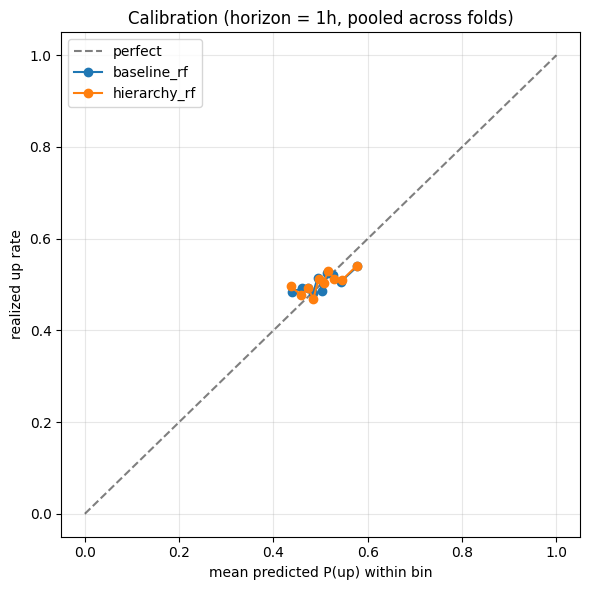


--- horizon = 4h, pooled across 5 folds ---
baseline_rf calibration:
           bin  mean_pp  up_rate   n
(0.279, 0.444] 0.424280 0.510379 819
(0.444, 0.458] 0.451503 0.493284 819
(0.458, 0.468] 0.463030 0.459096 819
(0.468, 0.479] 0.473272 0.523227 818
 (0.479, 0.49] 0.484306 0.512821 819
 (0.49, 0.503] 0.496224 0.490842 819
(0.503, 0.517] 0.509047 0.511002 818
(0.517, 0.539] 0.526744 0.510379 819
(0.539, 0.581] 0.557369 0.510379 819
(0.581, 0.732] 0.621930 0.532357 819

hierarchy_rf calibration:
           bin  mean_pp  up_rate   n
(0.239, 0.428] 0.403612 0.496947 819
(0.428, 0.451] 0.440703 0.495726 819
(0.451, 0.467] 0.459775 0.518926 819
(0.467, 0.482] 0.474180 0.492665 818
(0.482, 0.495] 0.488045 0.483516 819
(0.495, 0.512] 0.503009 0.473748 819
 (0.512, 0.53] 0.520359 0.529340 818
 (0.53, 0.555] 0.541919 0.534799 819
(0.555, 0.588] 0.570339 0.498168 819
(0.588, 0.707] 0.618422 0.529915 819


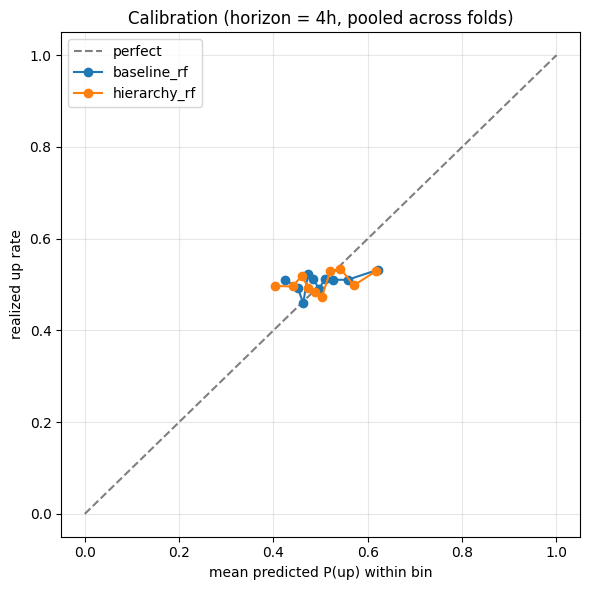

In [9]:
def pooled_calibration(preds_list, horizon, which="hier", n_bins=10):
    pps, ys = [], []
    for p in preds_list:
        if p["horizon"] != horizon: continue
        pps.append(p[f"pp_{which}"]); ys.append(p["y_true_cls"])
    pp = np.concatenate(pps); y = np.concatenate(ys)
    bins = pd.qcut(pp, q=n_bins, duplicates="drop")
    df = pd.DataFrame({"pp": pp, "y": y, "bin": bins})
    g = df.groupby("bin", observed=True).agg(
        mean_pp=("pp", "mean"), up_rate=("y", "mean"), n=("y", "size"),
    ).reset_index()
    return g, pp, y


for h in HORIZONS:
    cal_base, pp_b, y_b = pooled_calibration(all_preds, h, which="baseline")
    cal_hier, pp_h, y_h = pooled_calibration(all_preds, h, which="hier")
    print(f"\n--- horizon = {h}h, pooled across {N_FOLDS} folds ---")
    print("baseline_rf calibration:"); print(cal_base.to_string(index=False))
    print("\nhierarchy_rf calibration:"); print(cal_hier.to_string(index=False))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect")
    ax.plot(cal_base["mean_pp"], cal_base["up_rate"], "o-", label="baseline_rf")
    ax.plot(cal_hier["mean_pp"], cal_hier["up_rate"], "o-", label="hierarchy_rf")
    ax.set_xlabel("mean predicted P(up) within bin"); ax.set_ylabel("realized up rate")
    ax.set_title(f"Calibration (horizon = {h}h, pooled across folds)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## Hit ratio by |predicted return| decile (pooled, horizon=1h)

If the model is useful only when confident, the hit rate should grow with `|predicted_return|`. Flat curve = no usable confidence signal; monotone increasing = the model knows when it knows.



--- hit ratio by |predicted return| decile, horizon = 1h ---
baseline_rf:
 mean_abs_pr  hit_rate  mean_return_when_long   n
     0.00000   0.50361               -0.00010 830
     0.00001   0.51980               -0.00011 808
     0.00002   0.50818                0.00014 978
     0.00003   0.51442               -0.00001 659
     0.00004   0.50305                0.00001 819
     0.00005   0.50916               -0.00008 819
     0.00009   0.50367                0.00001 818
     0.00017   0.52381               -0.00008 819
     0.00038   0.50794                0.00012 819
     0.00121   0.51893                0.00021 819

hierarchy_rf:
 mean_abs_pr  hit_rate  mean_return_when_long   n
     0.00000   0.50794               -0.00017 819
     0.00001   0.53286                0.00007 837
     0.00002   0.51274                0.00006 903
     0.00003   0.47626                0.00011 716
     0.00004   0.53358                0.00001 819
     0.00006   0.51893               -0.00019 819
     0.000

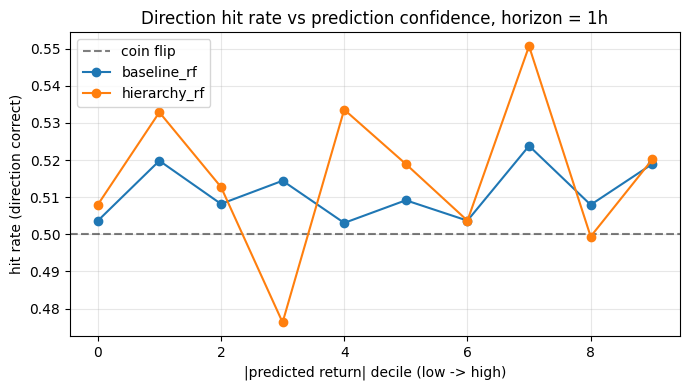


--- hit ratio by |predicted return| decile, horizon = 4h ---
baseline_rf:
 mean_abs_pr  hit_rate  mean_return_when_long   n
     0.00001   0.49343               -0.00017 837
     0.00003   0.47316               -0.00075 801
     0.00005   0.52259               -0.00021 819
     0.00007   0.48474               -0.00034 819
     0.00009   0.44200               -0.00028 819
     0.00015   0.50122                0.00009 818
     0.00029   0.48900               -0.00130 818
     0.00055   0.48962               -0.00183 819
     0.00128   0.48596               -0.00021 819
     0.00706   0.52625                0.00039 819

hierarchy_rf:
 mean_abs_pr  hit_rate  mean_return_when_long   n
     0.00001   0.52869               -0.00003 819
     0.00003   0.48840                0.00044 819
     0.00005   0.50484               -0.00012 826
     0.00007   0.49199                0.00050 811
     0.00010   0.46154               -0.00053 819
     0.00016   0.49573               -0.00021 819
     0.000

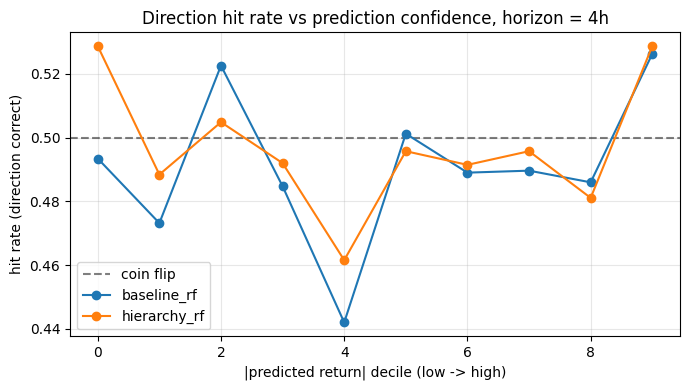

In [10]:
def pooled_hitratio_by_decile(preds_list, horizon, which="hier", n_bins=10):
    prs, ys = [], []
    for p in preds_list:
        if p["horizon"] != horizon: continue
        prs.append(p[f"pr_{which}"]); ys.append(p["y_true_reg"])
    pr = np.concatenate(prs); y = np.concatenate(ys)
    abs_bins = pd.qcut(np.abs(pr), q=n_bins, duplicates="drop")
    df = pd.DataFrame({"abs_pr": np.abs(pr), "pr": pr, "y": y, "bin": abs_bins})
    df["hit"] = (np.sign(df["pr"]) == np.sign(df["y"])).astype(int)
    g = df.groupby("bin", observed=True).agg(
        mean_abs_pr=("abs_pr", "mean"), hit_rate=("hit", "mean"),
        mean_return_when_long=("y", lambda s: float(s[df.loc[s.index, "pr"] > 0].mean()) if (df.loc[s.index, "pr"] > 0).any() else float("nan")),
        n=("y", "size"),
    ).reset_index(drop=True)
    return g


for h in HORIZONS:
    hr_base = pooled_hitratio_by_decile(all_preds, h, which="baseline")
    hr_hier = pooled_hitratio_by_decile(all_preds, h, which="hier")
    print(f"\n--- hit ratio by |predicted return| decile, horizon = {h}h ---")
    print("baseline_rf:"); print(hr_base.round(5).to_string(index=False))
    print("\nhierarchy_rf:"); print(hr_hier.round(5).to_string(index=False))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axhline(0.5, color="k", linestyle="--", alpha=0.5, label="coin flip")
    ax.plot(range(len(hr_base)), hr_base["hit_rate"], "o-", label="baseline_rf")
    ax.plot(range(len(hr_hier)), hr_hier["hit_rate"], "o-", label="hierarchy_rf")
    ax.set_xlabel("|predicted return| decile (low -> high)"); ax.set_ylabel("hit rate (direction correct)")
    ax.set_title(f"Direction hit rate vs prediction confidence, horizon = {h}h")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## IC across folds — is the signal stable or noisy?


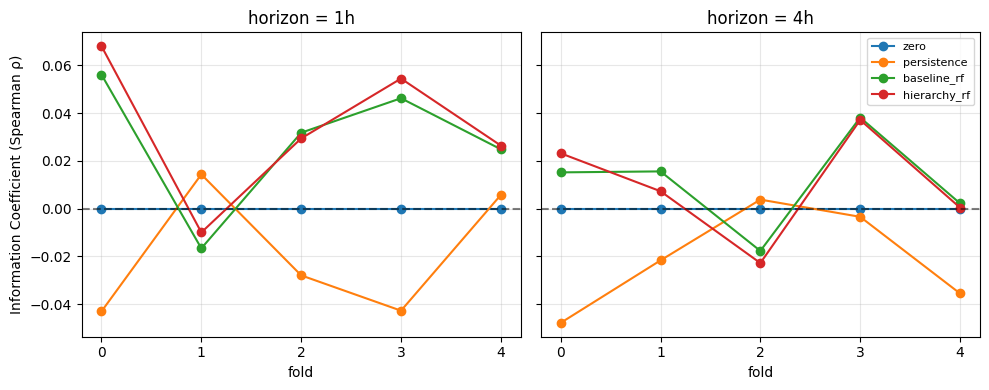

In [11]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 4), sharey=True)
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    sub = agg[(agg["kind"] == "regression") & (agg["horizon"] == h)]
    for m in ["zero", "persistence", "baseline_rf", "hierarchy_rf"]:
        rows = sub[sub["model"] == m].sort_values("fold")
        ax.plot(rows["fold"], rows["ic"], "o-", label=m)
    ax.axhline(0, color="k", linestyle="--", alpha=0.5)
    ax.set_title(f"horizon = {h}h"); ax.set_xlabel("fold"); ax.set_xticks(range(N_FOLDS))
    if ax is np.atleast_1d(axes)[0]: ax.set_ylabel("Information Coefficient (Spearman ρ)")
    ax.grid(True, alpha=0.3)
np.atleast_1d(axes)[-1].legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()


## Append to EXPERIMENTS.md


In [12]:
def append_to_journal(agg_df, all_info, journal_path=JOURNAL_PATH):
    header_needed = not os.path.exists(journal_path)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    config = {
        "notebook": "08_hourly_btc_walkforward.ipynb",
        "ticker": TICKER, "period": PERIOD, "interval": INTERVAL,
        "horizons_hours": HORIZONS, "n_folds": N_FOLDS,
        "min_train_fraction": MIN_TRAIN_FRACTION,
        "test_fraction_per_fold": TEST_FRACTION_PER_FOLD,
        "val_fraction_within_train": VAL_FRACTION_WITHIN_TRAIN,
        "max_hierarchy_depth": MAX_HIERARCHY_DEPTH,
        "min_leaf_count": MIN_LEAF_COUNT,
        "rf_n_estimators": RF_N_ESTIMATORS,
        "rf_grid": RF_GRID, "seed": SEED,
    }
    reg_summary = summarize(agg_df, "regression")
    cls_summary = summarize(agg_df, "classification")

    parts = []
    if header_needed:
        parts.append("# Experiments journal\n\n")
    parts.append("\n---\n")
    parts.append(f"\n## {timestamp} — NB08 hourly BTC-USD walk-forward (horizons={HORIZONS}h, K=4)\n")
    parts.append(f"\n**Config**\n\n```json\n{json.dumps(config, indent=2)}\n```\n")
    parts.append("\n**Regression summary (mean ± std across folds)**\n\n")
    parts.append("```\n")
    parts.append(str(reg_summary))
    parts.append("\n```\n\n**Classification summary (mean ± std across folds)**\n\n")
    parts.append("```\n")
    parts.append(str(cls_summary))
    parts.append("\n```\n")
    text = "".join(parts)
    with open(journal_path, "a") as f:
        f.write(text)
    print(f"Appended entry to {journal_path}")
    return text


journal_text = append_to_journal(agg, all_info)


Appended entry to EXPERIMENTS.md


## What an honest read looks like

1. **MAE / RMSE on log return.** Compare `baseline_rf` and `hierarchy_rf` to `zero` (predict no change) and `persistence` (predict last-period return). A tiny improvement (≤ 1%) over `zero` is plausible at 1h; anything substantially larger is suspicious.
2. **Information Coefficient.** A consistent positive IC across folds (e.g., +0.01 to +0.05) is what real intraday signal looks like in published quant work. A single fold with high IC and the rest near zero is overfitting.
3. **Balanced accuracy / ROC AUC for direction.** Expect 0.50–0.53. ROC AUC above 0.55 from OHLCV alone at hourly resolution would be unusual.
4. **Calibration plot.** Even a model with weak overall accuracy can be useful if its confidence is reliable — that's what the calibration curve checks. Look for the curve hugging y=x.
5. **Hit ratio by decile.** The most diagnostic plot for "is there usable signal." If the high-|prediction| deciles have hit rate > 0.55 and the low ones are ~0.50, the model has a meaningful confidence ranking even if average accuracy is mediocre.
6. **IC stability across folds.** If IC swings between +0.05 and −0.03, the apparent signal is noise. A consistent sign across all 5 folds is the bar.

Sign that the hierarchy helped: hierarchy_rf has higher IC and AUC than baseline_rf in 4 of 5 folds, and the calibration curve is closer to the diagonal. Sign that it didn't: the two curves are indistinguishable.
